In [84]:
import pandas as pd
import numpy as np
import scipy.stats as st
from numpy.linalg import lstsq
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv('exoplanets.csv', comment='#', low_memory=False)

df = df[['pl_rade', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'st_mass']]

In [85]:
df.shape

(39803, 5)

In [86]:
pl_mass_err = (df['pl_bmasseerr1'] + df['pl_bmasseerr2'])/2

In [90]:
sample_a = df.dropna()
print(sample_a.shape)


(2995, 5)


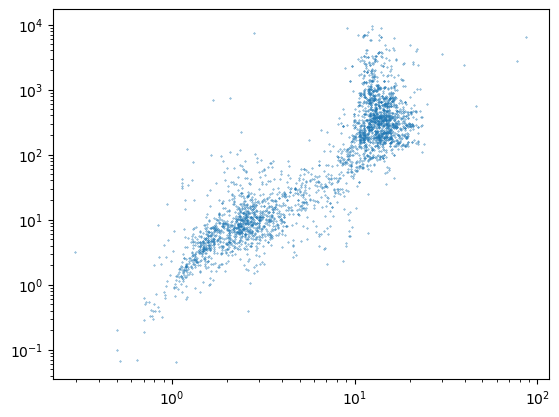

In [91]:
plt.scatter(sample_a['pl_rade'], sample_a['pl_bmasse'], s = 0.1)
plt.xscale('log')
plt.yscale('log')

In [142]:
sample_b = sample_a[(sample_a['pl_rade'] <= 5) & (sample_a['pl_rade']>=1)]
sample_b.shape

(1187, 5)

Task 2: linear regression

In [147]:
logM = np.log10(sample_b['pl_bmasse']).values
logR = np.log10(sample_b['pl_rade']).values

logR.shape

(1187,)

In [155]:
a, b, r, p, se =st.linregress(logR, logM)

print(a)

1.38574990914189


In [153]:
A = np.vstack([logR, np.ones(len(logR))]).T
slope, _= np.linalg.lstsq(A, logM)[0]
print(slope)
#print(c)

1.385749909141889


In [165]:
log_Rb = np.geomspace(logR.min(), logR.max(), 3000)
log_Mb = a*log_Rb + b


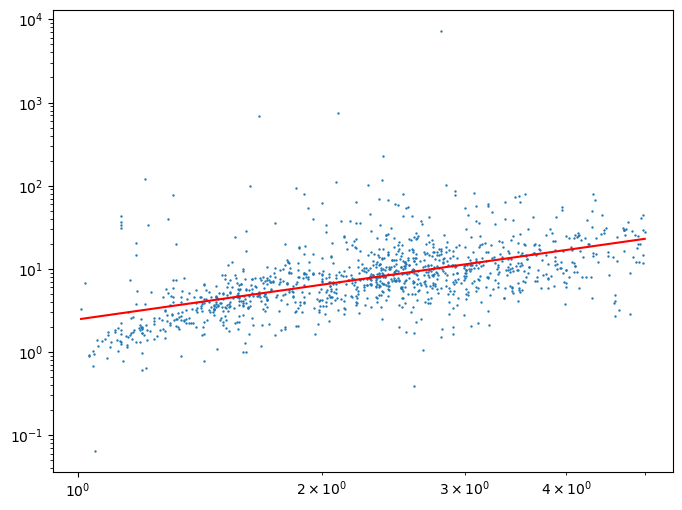

In [167]:
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(sample_b['pl_rade'], sample_b['pl_bmasse'], s= 0.5)
ax.plot(10**log_Rb, 10**log_Mb, color= 'r')
ax.set_yscale('log')
ax.set_xscale('log')

